In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path

# Get Total Bias

In [2]:
file_path = Path('/g/data/er8/users/cd3022/Irradiance-comparisons/')

tot_him = xr.open_dataset(
    f'{file_path}/himawari_ghi_means/himawari_monthly.nc',
    engine='h5netcdf'
)
tot_br2 = xr.open_dataset(
    f'{file_path}/barra-r2_ghi_means/barra-r2_monthly.nc',
    engine='h5netcdf'
)

tot_him = tot_him.interp(
    lat=tot_br2.lat,
    lon=tot_br2.lon,
    method='linear'
)

tot_diff = tot_br2.ghi - tot_him.ghi

# Weight mean by the number of days in the month
weights = xr.DataArray(
    [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31],
    dims="month"
)

total_bias = tot_diff.weighted(weights).mean("month")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


# CT Bias

In [4]:
ct_path = Path('/g/data/er8/users/cd3022/Irradiance-comparisons/cloud_types')

him_files = [f for f in ct_path.glob('himawari/*.nc')]
ds_him = xr.open_mfdataset(him_files, combine='nested', concat_dim='date', coords='minimal', compat='override')

bar_files = [f for f in ct_path.glob('barra-r2/*.nc')]
ds_br2 = xr.open_mfdataset(bar_files, combine='nested', concat_dim='date')

ct_freq = xr.open_dataset('/g/data/er8/users/cd3022/Irradiance-comparisons/cloud_types/TOTAL_FREQ_low.nc')

ct_ds = xr.open_zarr("/g/data/su28/himawari-ahi/cloud/ct/aus_regional_domain/S_NWC_CT_HIMA08_HIMA-N-NR.zarr/")

In [5]:
him_raw = xr.open_dataset('/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1d/latest/2020/01/01/IDE02326.202001010000.nc').isel(time=0)
him_raw = him_raw.rename(
    {
        'latitude': 'lat',
        'longitude': 'lon',
    }
)
him_raw = him_raw.interp(
    lat=ds_him.lat,
    lon=ds_him.lon,
    method='linear'
)
ds_him = ds_him.where(him_raw.daily_integral_of_surface_global_irradiance.notnull())

In [6]:
mean_him = ds_him.low_ghi.mean(dim='date')
mean_br2 = ds_br2.low_ghi.mean(dim='date')

In [7]:
mean_him = mean_him.interp(
    lat=mean_br2.lat,
    lon=mean_br2.lon,
    method='linear'
)

count = ct_freq.ct.interp(
    lat=mean_br2.lat,
    lon=mean_br2.lon,
    method='linear'
)

total = ct_ds.sel(time=slice('2016', '2024')).sizes['time']

freq = count / total

diff = mean_br2 - mean_him
comb = diff * freq
contribution = comb / total_bias * 100

# diff = diff.where(freq > 0.01)

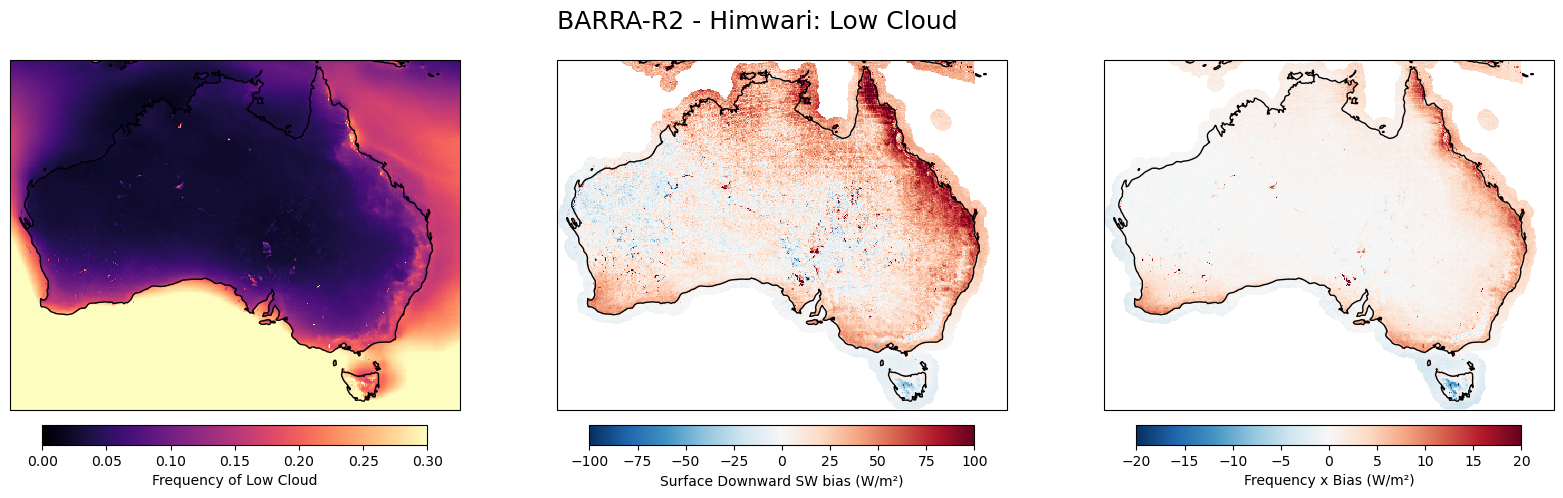

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5), subplot_kw={'projection': ccrs.PlateCarree()})

mesh_freq = ax[0].pcolormesh(
    freq.lon,
    freq.lat,
    freq,
    cmap='magma', shading='auto',
    vmin=0, vmax=0.3,
    transform=ccrs.PlateCarree()
)
mesh_diff = ax[1].pcolormesh(
    diff.lon,
    diff.lat,
    diff,
    cmap='RdBu_r', shading='auto',
    vmin=-100, vmax=100,
    transform=ccrs.PlateCarree()
)
mesh_comb = ax[2].pcolormesh(
    comb.lon,
    comb.lat,
    comb,
    cmap='RdBu_r', shading='auto',
    vmin=-20, vmax=20,
    transform=ccrs.PlateCarree()
)
ax[0].coastlines()
ax[1].coastlines()
ax[2].coastlines()
fig.suptitle(f'BARRA-R2 - Himawari: Low Cloud', fontsize=18)

cbar_freq= fig.colorbar(mesh_freq, ax=ax[0], orientation='horizontal', fraction=0.05, pad=0.04)
cbar_freq.set_label(f"Frequency of Low Cloud")
cbar_diff = fig.colorbar(mesh_diff, ax=ax[1], orientation='horizontal', fraction=0.05, pad=0.04)
cbar_diff.set_label("Surface Downward SW bias (W/m²)")
cbar_comb = fig.colorbar(mesh_comb, ax=ax[2], orientation='horizontal', fraction=0.05, pad=0.04)
cbar_comb.set_label("Frequency x Bias (W/m²)")
plt.savefig('/home/548/cd3022/figures/Irradiance_comparisons/cloud_types/low_br2_bias.png', dpi=500)

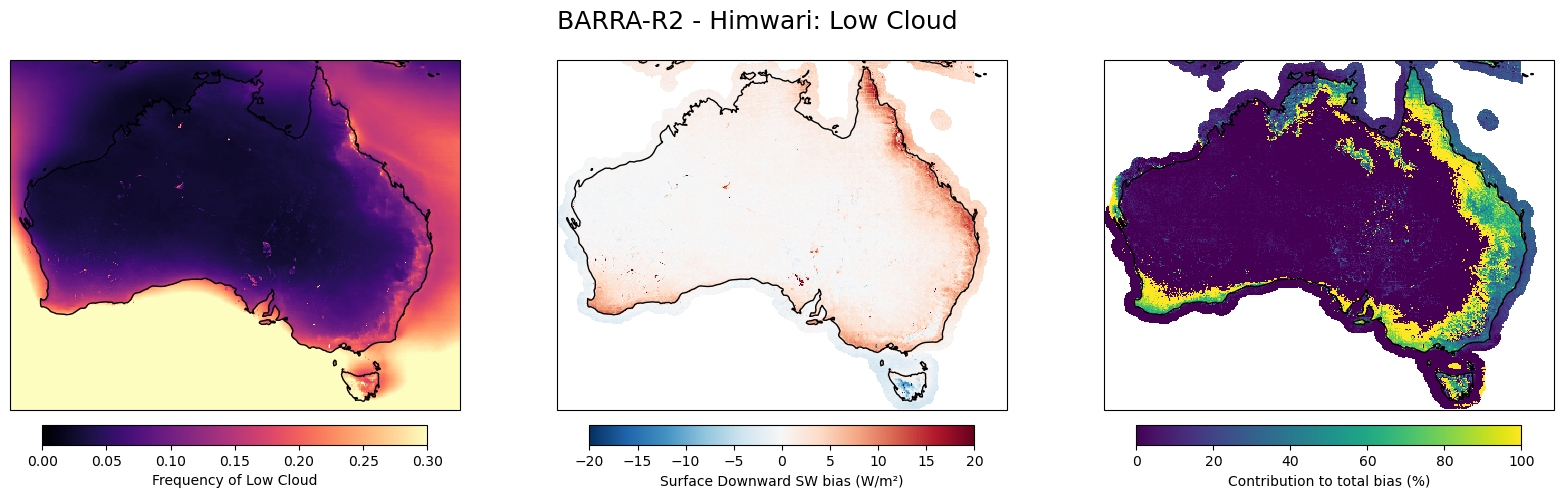

In [11]:
# fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5), subplot_kw={'projection': ccrs.PlateCarree()})

# mesh_freq = ax[0].pcolormesh(
#     freq.lon,
#     freq.lat,
#     freq,
#     cmap='magma', shading='auto',
#     vmin=0, vmax=0.3,
#     transform=ccrs.PlateCarree()
# )
# mesh_comb = ax[1].pcolormesh(
#     comb.lon,
#     comb.lat,
#     comb,
#     cmap='RdBu_r', shading='auto',
#     vmin=-20, vmax=20,
#     transform=ccrs.PlateCarree()
# )
# mesh_cont = ax[2].pcolormesh(
#     contribution.lon,
#     contribution.lat,
#     contribution,
#     cmap='viridis', shading='auto',
#     vmin=0, vmax=100,
#     transform=ccrs.PlateCarree()
# )
# ax[0].coastlines()
# ax[1].coastlines()
# ax[2].coastlines()
# fig.suptitle(f'BARRA-R2 - Himwari: Low Cloud', fontsize=18)

# cbar_freq= fig.colorbar(mesh_freq, ax=ax[0], orientation='horizontal', fraction=0.05, pad=0.04)
# cbar_freq.set_label(f"Frequency of Low Cloud")
# cbar_comb = fig.colorbar(mesh_comb, ax=ax[1], orientation='horizontal', fraction=0.05, pad=0.04)
# cbar_comb.set_label("Surface Downward SW bias (W/m²)")
# cbar_comb = fig.colorbar(mesh_cont, ax=ax[2], orientation='horizontal', fraction=0.05, pad=0.04)
# cbar_comb.set_label("Contribution to total bias (%)")
# plt.savefig('/home/548/cd3022/figures/Irradiance_comparisons/cloud_types/low_br2_bias.png', dpi=500)

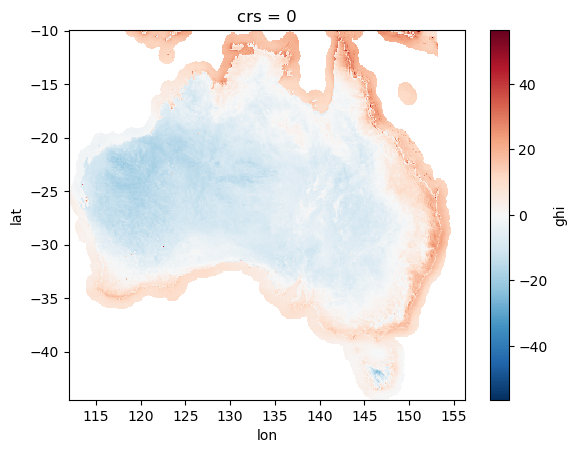

In [13]:
total_bias.plot()